In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver 
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests

from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)



In [5]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

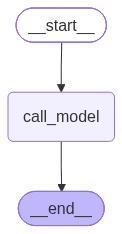

In [7]:
graph = builder.compile()
graph

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Varun."}]})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='Hi! My name is Varun.', additional_kwargs={}, response_metadata={}, id='9fbdcf56-cb0b-4450-ad32-e91651ab3cfe'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Varun! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EpAGCo0GARFNMg8igDBgwiR2+A1VUbobJkyqQSMe5qlpVz0+YaYtz0kcGbNs4X685J5RZ9tWEi8Ktpp3Nt8OfuNNE8YfSzy2TuDppk4jsdLEx1tpbd7ydPseQmRDJ/U5aUn+ug/LvmlCkwwvqFueQ+gkZrk2Evsms2eRSYjKrhHfusLSqdCQLUsvkv3dKzZZyOeqFqTvtOq8VnTMMbPONbdqV/CF5CDgfJbr5DkxHsJMPM9/Uxq58jcPMgXRFDMgj+1BCFwmr30mnlPRxVkYBlA/L02hvjC7NEo8PCGI3F2XDlxQ/QoNP84ZEkm1f/hYG4Ob4gBf8+zB8KllceT3tLdMJ64zEI45eucMJJ9DP7aT47Zm8lZJoCy5uGgARtbO65/gABMr8vHXD/7GlEitBFKSkbLHu0RtVcEuWjiP7Ed0ID4J2Mua6QrRMMWPhNzllD0vDu5jcSOTI4EsqfkD3aXG2zYlnM1s1mejN+iAWrsWWFYHyzNz9zRV7EzBMVQAfI7d/WRcZGECiOg0eE5riugD78cEWD4sG+2gnzD3wOo0XOB/aQdnBwUltvgnaGHYx/8wP1qFuZZKWG6Ptu5/vJPEVVpu4RThOuYoBT+yjDsUMntD7xPh9eEhvYyFFS41J2H/MzXKEmfY+M+mvnApEXD8Cq+bvvXic/1lh750RtPwJos+M/Wpn+Jpbva365t35oDIBJTjFp8ROd

In [9]:

graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='1de3ba1e-b0a5-442b-97b0-5c3d67b1bf72'),
  AIMessage(content=[{'type': 'text', 'text': "I don't know your name yet, since we just started chatting! What would you like me to call you?", 'extras': {'signature': 'ErcFCrQFARFNMg80jmMRKHXmX4whNbn9D+R5SSbZtQfmPbT8NMzJTVFlwAP+6SpXUXnJbXN3YMnV3trZa0tUUyFBrGWbnfj1Qi7+T5OYFzuevTCEsnGOS0wXDrjmXnX8SOrwfplWBoYxAQ7MiA3oWrUopiS6HXlgPqCpxSpmYr1tIkpYpukJHYnHJlNT0W7KOv0RDGaYMB83uXiNyxoPn17zPKGRM1N3xuY8X84b66QNrUNWSSMc4an1iow1jY7EoQ/u7QhBOPZNHuL7ZYUorA5w13JvWKfm871eRH36ZmU0H7c9zClQqhMWpV9zzvJtNhDD0C+9C77PDkOYHwyUbUjjCNDlFyeD1qiLFzc7yTkwXBsxHAwKiGri+KOJj6RMjznwbZu2g5mnNS873vp08hJvFP5AFjfFfPnId4oJxme1RmmmXOHiGrwXSHZyM7gQFPRTTGsQveoTU+mH9GH9ZuPdPpm9qw+dmuFTLF71kSZjQmtnU57klh7a0Y78mVqRHQCgUAnzkwbX4dLF6t1ako12W1ClaG/aV1hEdjlfSF8WEf4nL4QuPgMyeeuFPeH9kJfSfv+YQuWAVpq9x+MFrFaR/PaTtIWaNefnntNFV7BwLGB9WKx9fuma/+TIB7x5EfLj2SKUE4C4cM8ezUGR6UPMQ+2RnoYc6N8wp3t+JOQGBC2

In [10]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [13]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [14]:

config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [15]:

graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='2164d57e-6dfa-45e6-b6b4-9075ed1f9283'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Nitish! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvwFCvkFARFNMg+kjTrQWtCF4CaqJPqKb9Uh5DvWx7iNZc5EtFy++LVnP0j4tvSd7L6/6vG1y7QUrfSjBjPwPeWIfL2vDzvPg5l+JnEmURHIhyI94ctRrTUoWhcihTP6fXVEHdAu+iXVEgzHJLpdpN9QoyJsFiM9yTogPKoB3WeFhpI24Wgz1hHdHKJ4BalS2JByy5FjE6c1oa23jAsurZKLCPCqY3pgxRoTZQ9w+VDYBcKjSC32xYYQVFOJa62mu6vPwEdgtgatVCXCWSk0bnws0FljomAq6hXvRuZJSpKFlzFMNAu7ulzq1ifyAuWbm0a8wH/F6sN8qGVc1FQ33e+oOER3+j+f42JZCavHJYpB3lAL1BGpuo8XjhBswuY2Yb9PUX1ZB6zsTP+mWASgxT8p2YqoQiXJQM+3KddEWUmDXVI8GEj3P2wwxGhkZC6w8jkyK490DtGL8r3lCq+fqJDlrqBEkOSEGmxUyyD8zbBxgEyFoKkmnKe69MLoD+7QVSO6wBBozH9QnIlXixIdhoJjJBkpyuFJcpRK+D2hdCDF9ipFp5ZSTug3IUo6bqarZArXm6BQOd0zaxMqrimrOuysBOy+ZasvIVOMdkhxe03E6gx3Pc7QFtuPnqmmZZDIVaEGpNbO98tEdaPal+MRPNul5YcqbFTdcnRCHMcRDj6InvAicLaGF/l3pWUfjj99KkJovM52+O0I

In [18]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Nitish.', additional_kwargs={}, response_metadata={}, id='2164d57e-6dfa-45e6-b6b4-9075ed1f9283'),
  AIMessage(content=[{'type': 'text', 'text': "Hi Nitish! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvwFCvkFARFNMg+kjTrQWtCF4CaqJPqKb9Uh5DvWx7iNZc5EtFy++LVnP0j4tvSd7L6/6vG1y7QUrfSjBjPwPeWIfL2vDzvPg5l+JnEmURHIhyI94ctRrTUoWhcihTP6fXVEHdAu+iXVEgzHJLpdpN9QoyJsFiM9yTogPKoB3WeFhpI24Wgz1hHdHKJ4BalS2JByy5FjE6c1oa23jAsurZKLCPCqY3pgxRoTZQ9w+VDYBcKjSC32xYYQVFOJa62mu6vPwEdgtgatVCXCWSk0bnws0FljomAq6hXvRuZJSpKFlzFMNAu7ulzq1ifyAuWbm0a8wH/F6sN8qGVc1FQ33e+oOER3+j+f42JZCavHJYpB3lAL1BGpuo8XjhBswuY2Yb9PUX1ZB6zsTP+mWASgxT8p2YqoQiXJQM+3KddEWUmDXVI8GEj3P2wwxGhkZC6w8jkyK490DtGL8r3lCq+fqJDlrqBEkOSEGmxUyyD8zbBxgEyFoKkmnKe69MLoD+7QVSO6wBBozH9QnIlXixIdhoJjJBkpyuFJcpRK+D2hdCDF9ipFp5ZSTug3IUo6bqarZArXm6BQOd0zaxMqrimrOuysBOy+ZasvIVOMdkhxe03E6gx3Pc7QFtuPnqmmZZDIVaEGpNbO98tEdaPal+MRPNul5YcqbFTdcnRCHMcRDj6InvAicLaGF/l3pWUfjj99KkJovM52+O0I

In [17]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Nitish.
- AIMessage : [{'type': 'text', 'text': "Hi Nitish! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvwFCvkFARFNMg+kjTrQWtCF4CaqJPqKb9Uh5DvWx7iNZc5EtFy++LVnP0j4tvSd7L6/6vG1y7QUrfSjBjPwPeWIfL2vDzvPg5l+JnEmURHIhyI94ctRrTUoWhcihTP6fXVEHdAu+iXVEgzHJLpdpN9QoyJsFiM9yTogPKoB3WeFhpI24Wgz1hHdHKJ4BalS2JByy5FjE6c1oa23jAsurZKLCPCqY3pgxRoTZQ9w+VDYBcKjSC32xYYQVFOJa62mu6vPwEdgtgatVCXCWSk0bnws0FljomAq6hXvRuZJSpKFlzFMNAu7ulzq1ifyAuWbm0a8wH/F6sN8qGVc1FQ33e+oOER3+j+f42JZCavHJYpB3lAL1BGpuo8XjhBswuY2Yb9PUX1ZB6zsTP+mWASgxT8p2YqoQiXJQM+3KddEWUmDXVI8GEj3P2wwxGhkZC6w8jkyK490DtGL8r3lCq+fqJDlrqBEkOSEGmxUyyD8zbBxgEyFoKkmnKe69MLoD+7QVSO6wBBozH9QnIlXixIdhoJjJBkpyuFJcpRK+D2hdCDF9ipFp5ZSTug3IUo6bqarZArXm6BQOd0zaxMqrimrOuysBOy+ZasvIVOMdkhxe03E6gx3Pc7QFtuPnqmmZZDIVaEGpNbO98tEdaPal+MRPNul5YcqbFTdcnRCHMcRDj6InvAicLaGF/l3pWUfjj99KkJovM52+O0IoPHU1/rb/mVFP8sPtBwesHavyQfk0nAR/tmkmF6LEjBOH/UHk9RSEvLN5ArmOZxT4m+O7pqdKmSJLDNcioTaFGTHRmOMHvIJzvG1Gi1ELh3hSqntxDS